## <Center>Prediction of Car Sales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
## import packages for statistical models and Ml model
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error , mean_absolute_error , mean_absolute_percentage_error , r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Business Context

A car company wants to make a new car model that can sell very well.

To do this, they first want to understand:

What factors increase car sales
(for example: price, mileage, engine size, brand, safety, features, etc.)

After finding these important factors, they want to:

Predict how many cars may be sold for a new car model based on those factors.

In [2]:
car_sales = pd.read_csv(r"C:\Users\visha\OneDrive\Desktop\python for data science files\Car_sales - 1771155175098.csv")

In [3]:
car_sales.head(6)

,Manufacturer,Model,Sales_in_thousands,four_year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,02-02-2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,06-03-2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,01-04-2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,03-10-2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10-08-2011,62.777639
5,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,08-09-2011,84.565105


## Description of the Variables
1.Manufacturer – Car manufacturer name<br>
2.Model – Car model name<br>
3.Sales_in_thousands – Car sales in thousands<br>
4.__year_resale_value – Resale value after 4 years<br>
5.Vehicle_type – Type of car<br>
6.Price_in_thousands – Price of the car<br>
7.Engine_size – Car engine size<br>
8.Horsepower – Car horsepower<br>
9.Wheelbase – Distance between front and rear wheels<br>
10.Width – Car width<br>
11.Length – Car length<br>
12.Curb_weight – Car weight<br>
13.Fuel_capacity – Fuel tank capacity in liters<br>
14.Fuel_efficiency – Fuel efficiency (km per liter)<br>
15.Latest_Launch – Car model launch date<br>
16.Power_perf_factor – Power performance factor

In [4]:
car_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Manufacturer            157 non-null    object 
 1   Model                   157 non-null    object 
 2   Sales_in_thousands      157 non-null    float64
 3   four_year_resale_value  121 non-null    float64
 4   Vehicle_type            157 non-null    object 
 5   Price_in_thousands      155 non-null    float64
 6   Engine_size             156 non-null    float64
 7   Horsepower              156 non-null    float64
 8   Wheelbase               156 non-null    float64
 9   Width                   156 non-null    float64
 10  Length                  156 non-null    float64
 11  Curb_weight             155 non-null    float64
 12  Fuel_capacity           156 non-null    float64
 13  Fuel_efficiency         154 non-null    float64
 14  Latest_Launch           157 non-null    ob

In [5]:
car_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Sales_in_thousands,157.0,52.998076,68.029422,0.110000,14.114000,29.450000,67.956000,540.561000
four_year_resale_value,121.0,18.072975,11.453384,5.160000,11.260000,14.180000,19.875000,67.550000
Price_in_thousands,155.0,27.390755,14.351653,9.235000,18.017500,22.799000,31.947500,85.500000
Engine_size,156.0,3.060897,1.044653,1.000000,2.300000,3.000000,3.575000,8.000000
Horsepower,156.0,185.948718,56.700321,55.000000,149.500000,177.500000,215.000000,450.000000
Wheelbase,156.0,107.487179,7.641303,92.600000,103.000000,107.000000,112.200000,138.700000
Width,156.0,71.150000,3.451872,62.600000,68.400000,70.550000,73.425000,79.900000
Length,156.0,187.343590,13.431754,149.400000,177.575000,187.900000,196.125000,224.500000
Curb_weight,155.0,3.378026,0.630502,1.895000,2.971000,3.342000,3.799500,5.572000
Fuel_capacity,156.0,17.951923,3.887921,10.300000,15.800000,17.200000,19.575000,32.000000


In [6]:
car_sales.nunique()

Manufacturer               30
Model                     156
Sales_in_thousands        157
four_year_resale_value    117
Vehicle_type                2
Price_in_thousands        152
Engine_size                31
Horsepower                 66
Wheelbase                  88
Width                      78
Length                    127
Curb_weight               147
Fuel_capacity              55
Fuel_efficiency            20
Latest_Launch             130
Power_perf_factor         154
dtype: int64

In [7]:
correlation_between_columns = car_sales.select_dtypes(include = 'number')
correlation_between_columns.corr().T

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
Sales_in_thousands,1.000000,-0.279034,-0.304734,0.019983,-0.197756,0.358179,0.140918,0.254980,0.008628,0.086540,-0.016764,-0.223252
four_year_resale_value,-0.279034,1.000000,0.953840,0.531330,0.769081,-0.052270,0.178767,0.026548,0.361557,0.325567,-0.399880,0.827123
Price_in_thousands,-0.304734,0.953840,1.000000,0.626875,0.839744,0.110513,0.329136,0.156935,0.526224,0.423282,-0.492157,0.897945
Engine_size,0.019983,0.531330,0.626875,1.000000,0.837360,0.472130,0.690398,0.541424,0.760043,0.663022,-0.734622,0.818528
Horsepower,-0.197756,0.769081,0.839744,0.837360,1.000000,0.286308,0.539158,0.393364,0.610131,0.499907,-0.611332,0.992994
Wheelbase,0.358179,-0.052270,0.110513,0.472130,0.286308,1.000000,0.683135,0.839639,0.651016,0.654044,-0.497931,0.258852
Width,0.140918,0.178767,0.329136,0.690398,0.539158,0.683135,1.000000,0.710435,0.720927,0.656302,-0.602546,0.512025
Length,0.254980,0.026548,0.156935,0.541424,0.393364,0.839639,0.710435,1.000000,0.627163,0.563540,-0.446756,0.354095
Curb_weight,0.008628,0.361557,0.526224,0.760043,0.610131,0.651016,0.720927,0.627163,1.000000,0.863968,-0.818402,0.612071
Fuel_capacity,0.086540,0.325567,0.423282,0.663022,0.499907,0.654044,0.656302,0.563540,0.863968,1.000000,-0.801512,0.501184


## How to get total number of rows 

In [8]:
car_sales.shape

(157, 16)

In [9]:
car_sales.shape[0]

157

## How to get total number of rows in a column

In [10]:
car_sales.four_year_resale_value.shape[0]

157

## How to get total null values in a DF

In [11]:
car_sales.isna().sum()

Manufacturer               0
Model                      0
Sales_in_thousands         0
four_year_resale_value    36
Vehicle_type               0
Price_in_thousands         2
Engine_size                1
Horsepower                 1
Wheelbase                  1
Width                      1
Length                     1
Curb_weight                2
Fuel_capacity              1
Fuel_efficiency            3
Latest_Launch              0
Power_perf_factor          2
dtype: int64

## How to get total null values in a column

In [12]:
car_sales.four_year_resale_value.isna().sum()

np.int64(36)

## How to get percentage of total null values in a column

In [13]:
float((car_sales.four_year_resale_value.isna().sum()/car_sales.shape[0]) * 100)

22.929936305732486

## EDA ON NUMERIC COLUMNS

In [14]:
def continuous_var_summary( x ):
    
    # freq and missings in each variable
    
    n_total = x.shape[0]                # total rows in each variable
    n_miss = x.isna().sum()             # no. of missing values in each column
    perc_miss = n_miss * 100 / n_total  # %age of missing values
    
    # outliers - iqr
    
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lc_iqr = q1 - 1.5 * iqr
    uc_iqr = q3 + 1.5 * iqr
    
    return( pd.Series( [ x.dtype, x.nunique(), n_total, x.count(), n_miss, perc_miss,
                       x.sum(), x.mean(), x.std(), x.var(), 
                       lc_iqr, uc_iqr, 
                       x.min(), x.quantile(0.01), x.quantile(0.05), x.quantile(0.10), 
                       x.quantile(0.25), x.quantile(0.5), x.quantile(0.75), 
                       x.quantile(0.90), x.quantile(0.95), x.quantile(0.99), x.max() ], 
                     
                    index = ['dtype', 'cardinality', 'n_tot', 'n', 'nmiss', 'perc_miss',
                             'sum', 'mean', 'std', 'var','lc_iqr', 'uc_iqr',
                        'min', 'p1', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99', 'max'])) 

In [15]:
cars_numeric_columns_name =  car_sales.select_dtypes(include = 'float64').columns
cars_numeric_columns_name

Index(['Sales_in_thousands', 'four_year_resale_value', 'Price_in_thousands',
       'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length',
       'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor'],
      dtype='object')

In [16]:
car_sales[cars_numeric_columns_name].apply(continuous_var_summary)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
cardinality,157,117,152,31,66,88,78,127,147,55,20,154
n_tot,157,157,157,157,157,157,157,157,157,157,157,157
n,157,121,155,156,156,156,156,156,155,156,154,155
nmiss,0,36,2,1,1,1,1,1,2,1,3,2
perc_miss,0.0,22.929936,1.273885,0.636943,0.636943,0.636943,0.636943,0.636943,1.273885,0.636943,1.910828,1.273885
sum,8320.698,2186.83,4245.567,477.5,29008.0,16768.0,11099.4,29225.6,523.594,2800.5,3672.0,11941.756636
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.15,187.34359,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
var,4628.002257,131.180007,205.969949,1.0913,3214.926385,58.389512,11.915419,180.412023,0.397532,15.115932,18.341567,632.153558


## car_sales[cars_numeric_columns_name] ==
## car_sales['Sales_in_thousands', 'four_year_resale_value', 'Price_in_thousands','Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length','Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor']
     

## car_sales[cars_numeric_columns_name].apply(continuous_var_summary) == 
## continuous_var_summary(car_sales['Sales_in_thousands'])
## continuous_var_summary(car_sales['four_year_resale_value'])
## continuous_var_summary(car_sales['Price_in_thousands'])
# .apply() combines all those Series together into a DataFrame.

## we have seen many columns have outliers

# outliers treatment in numeric columns using percentile method

In [17]:
cars_numeric_column = car_sales[cars_numeric_columns_name].apply(lambda x : x.clip(lower = x.quantile(0.01) , upper = x.quantile(0.99)))
cars_numeric_column

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
0,16.919,16.360,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,58.280150
1,39.384,19.875,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,91.370778
2,14.114,18.225,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,NaN
3,8.588,29.725,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,91.389779
4,20.397,22.255,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...
152,3.545,NaN,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,66.498812
153,15.245,NaN,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,70.654495
154,17.531,NaN,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,71.155978
155,3.493,NaN,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,101.623357


##  car_sales[cars_numeric_columns_name].apply(lambda x : x.clip(lower = x.quantile(0.01) , upper = x.quantile(0.99))) is basically:
## car_sales[Sales_in_thousands] : car_sales[Sales_in_thousands.clip].clip(lower = x.quantile(0.01) , upper = x.quantile(0.99))
## car_sales[four_year_resale_value] : car_sales[four_year_resale_value].clip(lower = x.quantile(0.01) , upper = x.quantile(0.99)) and so on

In [18]:
cars_numeric_column.apply(continuous_var_summary)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
cardinality,155,115,150,29,64,87,76,125,145,54,19,152
n_tot,157,157,157,157,157,157,157,157,157,157,157,157
n,157,121,155,156,156,156,156,156,155,156,154,155
nmiss,0,36,2,1,1,1,1,1,2,1,3,2
perc_miss,0.0,22.929936,1.273885,0.636943,0.636943,0.636943,0.636943,0.636943,1.273885,0.636943,1.910828,1.273885
sum,8025.5292,2180.421,4235.95548,475.81,28910.3,16760.1,11102.45,29223.94,523.77016,2799.9,3660.0,11911.685368
mean,51.11802,18.020008,27.328745,3.050064,185.322436,107.436538,71.169551,187.332949,3.379162,17.948077,23.766234,76.849583
std,57.722699,11.181335,14.06397,0.982279,52.81647,7.424295,3.390339,13.12035,0.621764,3.819854,3.994755,23.844968
var,3331.909938,125.02226,197.795238,0.964871,2789.579526,55.120156,11.4944,172.143594,0.386591,14.591287,15.958068,568.58248


## Treating isna() values

In [19]:
cars_numeric_column = cars_numeric_column.apply(lambda x : x.fillna(x.mean()))
cars_numeric_column.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sales_in_thousands      157 non-null    float64
 1   four_year_resale_value  157 non-null    float64
 2   Price_in_thousands      157 non-null    float64
 3   Engine_size             157 non-null    float64
 4   Horsepower              157 non-null    float64
 5   Wheelbase               157 non-null    float64
 6   Width                   157 non-null    float64
 7   Length                  157 non-null    float64
 8   Curb_weight             157 non-null    float64
 9   Fuel_capacity           157 non-null    float64
 10  Fuel_efficiency         157 non-null    float64
 11  Power_perf_factor       157 non-null    float64
dtypes: float64(12)
memory usage: 14.8 KB


#  EDA ON TEXT COLUMNS

In [20]:
cars_text_columns = car_sales.select_dtypes(include = 'object')
cars_text_columns

,Manufacturer,Model,Vehicle_type,Latest_Launch
0,Acura,Integra,Passenger,02-02-2012
1,Acura,TL,Passenger,06-03-2011
2,Acura,CL,Passenger,01-04-2012
3,Acura,RL,Passenger,03-10-2011
4,Audi,A4,Passenger,10-08-2011
...,...,...,...,...
152,Volvo,V40,Passenger,9/21/2011
153,Volvo,S70,Passenger,11/24/2012
154,Volvo,V70,Passenger,6/25/2011
155,Volvo,C70,Passenger,4/26/2011


In [21]:
cars_text_columns.describe()

,Manufacturer,Model,Vehicle_type,Latest_Launch
count,157,157,157,157
unique,30,156,2,130
top,Dodge,Neon,Passenger,10-05-2012
freq,11,2,116,2


## In cataegorical columns we only wants columns with low cardinality so that dummy variables can be made

In [22]:
cars_text_columns.nunique()

Manufacturer      30
Model            156
Vehicle_type       2
Latest_Launch    130
dtype: int64

In [23]:
cars_new_text_column =cars_text_columns[['Manufacturer' , 'Vehicle_type']]
cars_new_text_column.head(3)

,Manufacturer,Vehicle_type
0,Acura,Passenger
1,Acura,Passenger
2,Acura,Passenger


## Create dummy variables of these 2 categorical columns with pd.get_dummies()

In [24]:
## pd.get_dummies([cars_new_text_column.Manufacturer , cars_new_text_column.Vehicle_type]) ## This will give error don;t know why
cars_new_text_column = pd.get_dummies(cars_new_text_column, drop_first= True)
cars_new_text_column.rename(columns={'Manufacturer_Mercedes-B' : 'Manufacturer_Mercedes_B'} , inplace= True)
cars_new_text_column.head()

,Manufacturer_Audi,Manufacturer_BMW,Manufacturer_Buick,Manufacturer_Cadillac,Manufacturer_Chevrolet,Manufacturer_Chrysler,Manufacturer_Dodge,Manufacturer_Ford,Manufacturer_Honda,Manufacturer_Hyundai,...,Manufacturer_Plymouth,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [25]:
cars_new_text_column.columns

Index(['Manufacturer_Audi', 'Manufacturer_BMW', 'Manufacturer_Buick',
       'Manufacturer_Cadillac', 'Manufacturer_Chevrolet',
       'Manufacturer_Chrysler', 'Manufacturer_Dodge', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Infiniti',
       'Manufacturer_Jaguar', 'Manufacturer_Jeep', 'Manufacturer_Lexus',
       'Manufacturer_Lincoln', 'Manufacturer_Mercedes_B',
       'Manufacturer_Mercury', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Oldsmobile',
       'Manufacturer_Plymouth', 'Manufacturer_Pontiac', 'Manufacturer_Porsche',
       'Manufacturer_Saab', 'Manufacturer_Saturn', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen', 'Manufacturer_Volvo',
       'Vehicle_type_Passenger'],
      dtype='object')

## merge cars_new_text_column and cars_numeric_column

In [26]:
car_new = pd.concat([cars_numeric_column, cars_new_text_column] , axis= 1)
car_new

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Plymouth,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger
0,16.919,16.360000,21.500000,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875000,28.400000,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
2,14.114,18.225000,27.328745,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,True
3,8.588,29.725000,42.000000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,False,True
4,20.397,22.255000,23.990000,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,3.545,18.020008,24.400000,1.9,160.0,100.5,67.6,176.6,3.042,15.8,...,False,False,False,False,False,False,False,False,True,True
153,15.245,18.020008,27.500000,2.4,168.0,104.9,69.3,185.9,3.208,17.9,...,False,False,False,False,False,False,False,False,True,True
154,17.531,18.020008,28.800000,2.4,168.0,104.9,69.3,186.2,3.259,17.9,...,False,False,False,False,False,False,False,False,True,True
155,3.493,18.020008,45.500000,2.3,236.0,104.9,71.5,185.7,3.601,18.5,...,False,False,False,False,False,False,False,False,True,True


# Creating linear regression model without variable reduction that is with all X variables

## Seperate X and Y variable from car_new()
## df.columns.difference(['column_name']) is used to remove variable/column  name from list of columns we get from df.columns i.e returns all column names except the specified column(s).

In [27]:
# X variables
features = car_new.columns.difference(['Sales_in_thousands'])
features

Index(['Curb_weight', 'Engine_size', 'Fuel_capacity', 'Fuel_efficiency',
       'Horsepower', 'Length', 'Manufacturer_Audi', 'Manufacturer_BMW',
       'Manufacturer_Buick', 'Manufacturer_Cadillac', 'Manufacturer_Chevrolet',
       'Manufacturer_Chrysler', 'Manufacturer_Dodge', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Infiniti',
       'Manufacturer_Jaguar', 'Manufacturer_Jeep', 'Manufacturer_Lexus',
       'Manufacturer_Lincoln', 'Manufacturer_Mercedes_B',
       'Manufacturer_Mercury', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Oldsmobile',
       'Manufacturer_Plymouth', 'Manufacturer_Pontiac', 'Manufacturer_Porsche',
       'Manufacturer_Saab', 'Manufacturer_Saturn', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen', 'Manufacturer_Volvo',
       'Power_perf_factor', 'Price_in_thousands', 'Vehicle_type_Passenger',
       'Wheelbase', 'Width', 'four_year_resale_value'],
      dtype

## Train and test data split

In [28]:
train_data , test_data = train_test_split(car_new , train_size= 0.7 , test_size= 0.3)

## train_data , test_data = train_test_split() will return 2 things train data i.e 70 % of car_new and test data i.e 30 % of car_new and first variable store train data and second test data

In [29]:
train_data.shape

(109, 42)

In [30]:
test_data.shape

(48, 42)

## Making the equation Y ~ X i.e “Y depends on X” or “Predict Y from X”
## Sales_in_thousands ~ Price + Horsepower means Sales_in_thousands depends on Price and Horsepower.
## later gets converted into a mathematical linear regression equation like:
## Sales_in_thousands = b0+b1(Price)+b2(Horsepower)

In [31]:
formula0 = 'Sales_in_thousands ~ ' + " + ".join(features)
formula0

'Sales_in_thousands ~ Curb_weight + Engine_size + Fuel_capacity + Fuel_efficiency + Horsepower + Length + Manufacturer_Audi + Manufacturer_BMW + Manufacturer_Buick + Manufacturer_Cadillac + Manufacturer_Chevrolet + Manufacturer_Chrysler + Manufacturer_Dodge + Manufacturer_Ford + Manufacturer_Honda + Manufacturer_Hyundai + Manufacturer_Infiniti + Manufacturer_Jaguar + Manufacturer_Jeep + Manufacturer_Lexus + Manufacturer_Lincoln + Manufacturer_Mercedes_B + Manufacturer_Mercury + Manufacturer_Mitsubishi + Manufacturer_Nissan + Manufacturer_Oldsmobile + Manufacturer_Plymouth + Manufacturer_Pontiac + Manufacturer_Porsche + Manufacturer_Saab + Manufacturer_Saturn + Manufacturer_Subaru + Manufacturer_Toyota + Manufacturer_Volkswagen + Manufacturer_Volvo + Power_perf_factor + Price_in_thousands + Vehicle_type_Passenger + Wheelbase + Width + four_year_resale_value'

# Assumptions for working with Linear Regression Model:
## Linear Regression is based on many assumption, out of which 10 are critical.
## We will talk about 4 assumptions first. These assumptions are:
i. Residual = Actual value - Predicted value <br>
These residuals should roughly follow a normal (bell-shaped) distribution. <br>
Because: <br>
confidence intervals <br>
hypothesis testing <br>
p-values <br>
statistical significance <br>

all rely on this assumption.


ii.  The y variable must be linearly related to all x variables so that we can get the straight line, i.e.  best fit line will be selected.

iii. All X variables must be independent(To avoid multicollinearity).

iv.  No. of observations > no. of Columns

v. Y being approximately normally distributed is helpful in practice, but the actual regression assumption is about residuals being normal.

we often check Y because:

skewed Y often leads to skewed residuals<br>
transformations like log(Y) may improve model performance

## Check Y in normally distributed or not becuase if Y is highly skewed,then residuals also often become non-normally distributed.
## Reason 2 to check Y in normally distributed or not: If Y is higly skewed then errors become unstable and predictions become poor


## Ways to check Y is normal or not

(array([73., 34., 17., 13.,  4.,  5.,  3.,  1.,  3.,  4.]),
 array([  0.93728 ,  26.908084,  52.878888,  78.849692, 104.820496,
        130.7913  , 156.762104, 182.732908, 208.703712, 234.674516,
        260.64532 ]),
 <BarContainer object of 10 artists>)

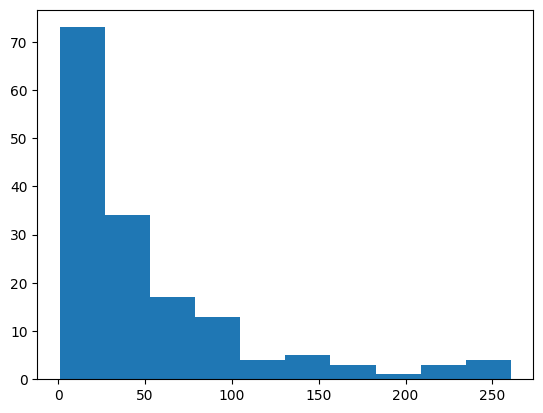

In [32]:
plt.hist(car_new.Sales_in_thousands)

C:\Users\visha\AppData\Local\Temp\ipykernel_35444\3033739231.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(car_new.Sales_in_thousands)


<Axes: xlabel='Sales_in_thousands', ylabel='Density'>

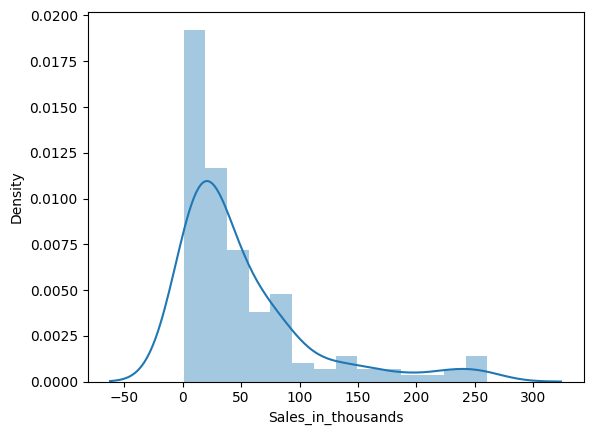

In [33]:
sns.distplot(car_new.Sales_in_thousands)

## Distribution is right-skewed

## To check data is skewed or not

In [34]:
car_new.Sales_in_thousands.skew() ##skew() > 0 :👉 Positive skew / right skew

np.float64(1.9924932920508793)

# Benefits of using log(Y) in a model
## we transform Y to log(Y) to reduce skewness and make the distribution of Y closer to normal this can Makes residuals closer to normal and Regression works better when residuals are approximately normal..
## it can reduce outlier impact if present
## Make relationship linear: Sometimes:X and Y are non-linear 
## After log:relationship becomes more linear


In [35]:
car_new['new_log_Sales_in_Thousands'] = np.log(car_new.Sales_in_thousands)
car_new.head()

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger,new_log_Sales_in_Thousands
0,16.919,16.360,21.500000,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,True,2.828437
1,39.384,19.875,28.400000,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,True,3.673360
2,14.114,18.225,27.328745,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,True,2.647167
3,8.588,29.725,42.000000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,True,2.150366
4,20.397,22.255,23.990000,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,True,3.015388


C:\Users\visha\AppData\Local\Temp\ipykernel_35444\2713091854.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(car_new.new_log_Sales_in_Thousands)


<Axes: xlabel='new_log_Sales_in_Thousands', ylabel='Density'>

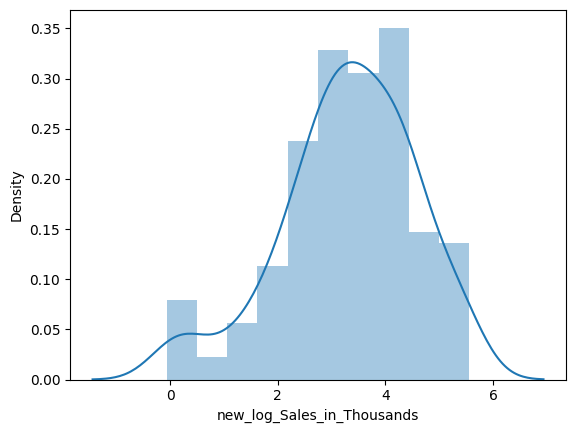

In [36]:
sns.distplot(car_new.new_log_Sales_in_Thousands)

In [37]:
car_new.new_log_Sales_in_Thousands.skew()

np.float64(-0.5925861100519006)

## new_log_Sales_in_Thousand is our new Y variable and old Sales_in_Thousand is neither Y nor X variable

## features = car_new.columns.difference(['Sales_in_thousands']) this becomes features = car_new.columns.difference(['Sales_in_thousands','new_log_Sales_in_Thousands'])
## formula0 = 'Sales_in_thousands ~ ' + " + ".join(features) this becomes formula0 = 'new_log_Sales_in_Thousands ~ ' + " + ".join(features)

In [38]:
features = car_new.columns.difference(['Sales_in_thousands','new_log_Sales_in_Thousands'])
features

Index(['Curb_weight', 'Engine_size', 'Fuel_capacity', 'Fuel_efficiency',
       'Horsepower', 'Length', 'Manufacturer_Audi', 'Manufacturer_BMW',
       'Manufacturer_Buick', 'Manufacturer_Cadillac', 'Manufacturer_Chevrolet',
       'Manufacturer_Chrysler', 'Manufacturer_Dodge', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Infiniti',
       'Manufacturer_Jaguar', 'Manufacturer_Jeep', 'Manufacturer_Lexus',
       'Manufacturer_Lincoln', 'Manufacturer_Mercedes_B',
       'Manufacturer_Mercury', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Oldsmobile',
       'Manufacturer_Plymouth', 'Manufacturer_Pontiac', 'Manufacturer_Porsche',
       'Manufacturer_Saab', 'Manufacturer_Saturn', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen', 'Manufacturer_Volvo',
       'Power_perf_factor', 'Price_in_thousands', 'Vehicle_type_Passenger',
       'Wheelbase', 'Width', 'four_year_resale_value'],
      dtype

In [39]:
 formula0 = 'new_log_Sales_in_Thousands ~ ' + " + ".join(features)
 formula0

'new_log_Sales_in_Thousands ~ Curb_weight + Engine_size + Fuel_capacity + Fuel_efficiency + Horsepower + Length + Manufacturer_Audi + Manufacturer_BMW + Manufacturer_Buick + Manufacturer_Cadillac + Manufacturer_Chevrolet + Manufacturer_Chrysler + Manufacturer_Dodge + Manufacturer_Ford + Manufacturer_Honda + Manufacturer_Hyundai + Manufacturer_Infiniti + Manufacturer_Jaguar + Manufacturer_Jeep + Manufacturer_Lexus + Manufacturer_Lincoln + Manufacturer_Mercedes_B + Manufacturer_Mercury + Manufacturer_Mitsubishi + Manufacturer_Nissan + Manufacturer_Oldsmobile + Manufacturer_Plymouth + Manufacturer_Pontiac + Manufacturer_Porsche + Manufacturer_Saab + Manufacturer_Saturn + Manufacturer_Subaru + Manufacturer_Toyota + Manufacturer_Volkswagen + Manufacturer_Volvo + Power_perf_factor + Price_in_thousands + Vehicle_type_Passenger + Wheelbase + Width + four_year_resale_value'

## We added new column to car_new i.e new_log_Sales_in_Thousands so we need to split data again so that train and test data also have that column

In [40]:
train_data , test_data = train_test_split(car_new , train_size= 0.7 , test_size= 0.3)

## Finding Best fit line
## we use smf.ols(formula , data).fit() here smf is  statsmodels.formula.api which ols functions that stands for Ordinary Least it finds coefficent that minimizes ∑(yi(actual)−yi(predicted))2 as much as possible

In [41]:
m =smf.ols(formula0 ,train_data).fit()
print(m.summary())

                                OLS Regression Results                                
Dep. Variable:     new_log_Sales_in_Thousands   R-squared:                       0.769
Model:                                    OLS   Adj. R-squared:                  0.628
Method:                         Least Squares   F-statistic:                     5.454
Date:                        Fri, 12 Jun 2026   Prob (F-statistic):           5.10e-10
Time:                                15:56:55   Log-Likelihood:                -84.983
No. Observations:                         109   AIC:                             254.0
Df Residuals:                              67   BIC:                             367.0
Df Model:                                  41                                         
Covariance Type:                    nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

## P-value checks whether a variable is actually helping predict Y. p < 0.05	variable is significant → keep it and p > 0.05	variable is not significant → may remove it

## steps to perform after summary
step 1: predict Y on both train and test data

m.predict(train)<br>
m.predict(test)

step 2: test the accuracy of the model

MAPE<BR>
RMSE<BR>
CORRELATION BETWEEN ACTUAL AND PREDICTED<BR>
DECILE ANALYSIS<br>
R squared and adjusted R squared


## Model with important X variables

In [42]:
formula1 = 'new_log_Sales_in_Thousands ~ Fuel_efficiency+Manufacturer_Ford+Manufacturer_Plymouth+Price_in_thousands+Vehicle_type_Passenger+Wheelbase'

In [43]:
m1 = smf.ols(formula1 , train_data).fit()
print(m1.summary())

                                OLS Regression Results                                
Dep. Variable:     new_log_Sales_in_Thousands   R-squared:                       0.630
Model:                                    OLS   Adj. R-squared:                  0.608
Method:                         Least Squares   F-statistic:                     28.94
Date:                        Fri, 12 Jun 2026   Prob (F-statistic):           5.35e-20
Time:                                15:56:56   Log-Likelihood:                -110.77
No. Observations:                         109   AIC:                             235.5
Df Residuals:                             102   BIC:                             254.4
Df Model:                                   6                                         
Covariance Type:                    nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

## The difference between R square and adjusted R squared becomes very small and  all P values are less then 0.05 so we can say model is good


## How we reached from all variables to specific variables which are important in prediction i.e variable reduction
## Variable reduction invovle 2 steps
#### 1. Feature importance = Out of all X variable we have to choose those which actually affecting Y and we have a function f_regression() for this work. f_regression() is a function in scikit-learn(sklearn) used for feature selection in regression. 
#### It checks:“How strongly each X variable is related to Y?” It returns It returns 2 arrays: f_score and p_value
#### 2. Multicollinearty check: After selecting important features we will check is there any multicollinearity between those variables

In [44]:
## Feature importance
from sklearn.feature_selection import f_regression

In [45]:
f_score,p_value = f_regression(car_new[features] , car_new.new_log_Sales_in_Thousands)
d = {'X_features' : features , 'f_score' : f_score , 'p_value' : p_value}

In [46]:
feature_imp = pd.DataFrame(d)
feature_imp

,X_features,f_score,p_value
0,Curb_weight,0.418695,5.185460e-01
1,Engine_size,2.302434,1.312083e-01
2,Fuel_capacity,0.059260,8.079907e-01
3,Fuel_efficiency,2.877548,9.183014e-02
4,Horsepower,29.616745,2.016940e-07
5,Length,6.954753,9.211207e-03
6,Manufacturer_Audi,2.874313,9.201122e-02
7,Manufacturer_BMW,0.726643,3.952886e-01
8,Manufacturer_Buick,1.196073,2.758046e-01
9,Manufacturer_Cadillac,0.887999,3.474866e-01


## At 90 % CI we keep only X variables whose p_value is less than 0.1

In [47]:
only_feature_imp = feature_imp.loc[feature_imp.p_value < 0.1,'X_features'].reset_index(drop = True)
only_feature_imp


0             Fuel_efficiency
1                  Horsepower
2                      Length
3           Manufacturer_Audi
4           Manufacturer_Ford
5          Manufacturer_Honda
6     Manufacturer_Mercedes_B
7       Manufacturer_Plymouth
8        Manufacturer_Porsche
9         Manufacturer_Toyota
10         Manufacturer_Volvo
11          Power_perf_factor
12         Price_in_thousands
13     Vehicle_type_Passenger
14                  Wheelbase
15     four_year_resale_value
Name: X_features, dtype: object

## Multi collinearty check of remaning X _ variables (VIF and dmatrices)

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

## new formula

In [49]:
formula2 = 'new_log_Sales_in_Thousands ~ ' + '+'.join(only_feature_imp)
formula2

'new_log_Sales_in_Thousands ~ Fuel_efficiency+Horsepower+Length+Manufacturer_Audi+Manufacturer_Ford+Manufacturer_Honda+Manufacturer_Mercedes_B+Manufacturer_Plymouth+Manufacturer_Porsche+Manufacturer_Toyota+Manufacturer_Volvo+Power_perf_factor+Price_in_thousands+Vehicle_type_Passenger+Wheelbase+four_year_resale_value'

## dmatrices : A function that automatically separates Y and X from a regression formula.
## It also:
## adds intercept column automatically
## creates dummy variables automatically of categorical column

In [50]:
Y,X = dmatrices(formula2 , car_new , return_type= 'dataframe' ) 

In [51]:
Y

,new_log_Sales_in_Thousands
0,2.828437
1,3.673360
2,2.647167
3,2.150366
4,3.015388
...,...
152,1.265538
153,2.724252
154,2.863971
155,1.250761


In [52]:
X

,Intercept,Manufacturer_Audi[T.True],Manufacturer_Ford[T.True],Manufacturer_Honda[T.True],Manufacturer_Mercedes_B[T.True],Manufacturer_Plymouth[T.True],Manufacturer_Porsche[T.True],Manufacturer_Toyota[T.True],Manufacturer_Volvo[T.True],Vehicle_type_Passenger[T.True],Fuel_efficiency,Horsepower,Length,Power_perf_factor,Price_in_thousands,Wheelbase,four_year_resale_value
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0,140.0,172.4,58.280150,21.500000,101.2,16.360000
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,25.0,225.0,192.9,91.370778,28.400000,108.1,19.875000
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,26.0,225.0,192.0,76.849583,27.328745,106.9,18.225000
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,22.0,210.0,196.6,91.389779,42.000000,114.6,29.725000
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,27.0,150.0,178.0,62.777639,23.990000,102.6,22.255000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,25.0,160.0,176.6,66.498812,24.400000,100.5,18.020008
153,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,25.0,168.0,185.9,70.654495,27.500000,104.9,18.020008
154,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,25.0,168.0,186.2,71.155978,28.800000,104.9,18.020008
155,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,23.0,236.0,185.7,101.623357,45.500000,104.9,18.020008


## Making a dataframe name VIF with first column as important feature names we got in above steps and their VIF value as another column to check multicollinearty
## variance_inflation_factor(X.values, i) 
## i index of column whose VIF we want

In [53]:
VIF = pd.DataFrame()

In [54]:
VIF['only_imporatant_features'] = X.columns
VIF['VIF_Value_of_Important_Features'] = [variance_inflation_factor(X.values , i ) for i in range(X.shape[1])]
VIF

,only_imporatant_features,VIF_Value_of_Important_Features
0,Intercept,644.058154
1,Manufacturer_Audi[T.True],1.073516
2,Manufacturer_Ford[T.True],1.091235
3,Manufacturer_Honda[T.True],1.092045
4,Manufacturer_Mercedes_B[T.True],1.722476
5,Manufacturer_Plymouth[T.True],1.181433
6,Manufacturer_Porsche[T.True],1.675094
7,Manufacturer_Toyota[T.True],1.173508
8,Manufacturer_Volvo[T.True],1.078381
9,Vehicle_type_Passenger[T.True],3.212098


## VIF value between 1-5 means low to low-moderate multicollinearty
 ## VIF value between 5-10 means High multicollinearty
## VIF value  >10 means Serious multicollinearty
## So basically VIF value should be less than 5

In [55]:
m2 = smf.ols(formula2 , train_data).fit()
print(m2.summary())

                                OLS Regression Results                                
Dep. Variable:     new_log_Sales_in_Thousands   R-squared:                       0.697
Model:                                    OLS   Adj. R-squared:                  0.644
Method:                         Least Squares   F-statistic:                     13.22
Date:                        Fri, 12 Jun 2026   Prob (F-statistic):           1.85e-17
Time:                                15:57:00   Log-Likelihood:                -99.883
No. Observations:                         109   AIC:                             233.8
Df Residuals:                              92   BIC:                             279.5
Df Model:                                  16                                         
Covariance Type:                    nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [56]:
formula2

'new_log_Sales_in_Thousands ~ Fuel_efficiency+Horsepower+Length+Manufacturer_Audi+Manufacturer_Ford+Manufacturer_Honda+Manufacturer_Mercedes_B+Manufacturer_Plymouth+Manufacturer_Porsche+Manufacturer_Toyota+Manufacturer_Volvo+Power_perf_factor+Price_in_thousands+Vehicle_type_Passenger+Wheelbase+four_year_resale_value'

## Removing unwanted features one by one

In [57]:
formula3  = 'new_log_Sales_in_Thousands ~ Fuel_efficiency+Manufacturer_Ford+Manufacturer_Plymouth+Price_in_thousands+Vehicle_type_Passenger+Wheelbase'

In [58]:
m3 = smf.ols(formula3 , train_data).fit()
print(m3.summary())

                                OLS Regression Results                                
Dep. Variable:     new_log_Sales_in_Thousands   R-squared:                       0.630
Model:                                    OLS   Adj. R-squared:                  0.608
Method:                         Least Squares   F-statistic:                     28.94
Date:                        Fri, 12 Jun 2026   Prob (F-statistic):           5.35e-20
Time:                                15:57:01   Log-Likelihood:                -110.77
No. Observations:                         109   AIC:                             235.5
Df Residuals:                             102   BIC:                             254.4
Df Model:                                   6                                         
Covariance Type:                    nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [59]:
train_data['y_predict'] = np.exp(m3.predict(train_data))

In [60]:
train_data

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger,new_log_Sales_in_Thousands,y_predict
78,22.925,18.020008,42.660,5.4,300.0,119.0,79.19,204.8,5.393,30.0,...,False,False,False,False,False,False,False,False,3.132228,24.991801
84,11.337,19.125000,31.807,3.5,200.0,107.3,69.90,186.6,4.520,24.3,...,False,False,False,False,False,False,False,False,2.428072,27.999393
88,67.956,11.030000,19.035,3.0,153.0,108.5,73.00,199.7,3.379,16.0,...,False,False,False,False,False,False,False,True,4.218860,53.603993
154,17.531,18.020008,28.800,2.4,168.0,104.9,69.30,186.2,3.259,17.9,...,False,False,False,False,False,False,True,True,2.863971,24.060076
1,39.384,19.875000,28.400,3.2,225.0,108.1,70.30,192.9,3.517,17.2,...,False,False,False,False,False,False,False,True,3.673360,28.419560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,24.155,12.025000,18.850,2.4,150.0,113.3,76.80,186.3,3.528,20.0,...,False,False,False,False,False,False,False,False,3.184491,15.273273
85,39.348,13.880000,22.527,3.0,173.0,107.3,66.70,178.3,3.510,19.5,...,False,False,False,False,False,False,False,False,3.672445,48.518960
25,32.299,9.125000,13.960,1.8,120.0,97.1,66.70,174.3,2.398,13.2,...,False,False,False,False,False,False,False,True,3.475036,37.229265
75,51.238,18.020008,34.605,3.0,220.0,103.0,71.50,180.1,3.900,17.2,...,False,False,False,False,False,False,False,False,3.936481,18.224086


In [61]:
test_data['y_predict'] = np.exp(m3.predict(test_data))

In [62]:
test_data

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger,new_log_Sales_in_Thousands,y_predict
18,14.78500,18.020008,46.2250,5.7,255.0,117.500,77.00,201.200,5.39668,30.0,...,False,False,False,False,False,False,False,False,2.693613,18.642050
27,107.99500,18.020008,18.8900,3.4,180.0,110.500,73.00,200.000,3.38900,17.0,...,False,False,False,False,False,False,False,True,4.682085,55.550076
98,11.59200,18.020008,41.6000,3.2,215.0,105.900,67.80,180.300,3.21300,16.4,...,False,False,False,False,False,False,False,True,2.450315,10.902446
49,245.81500,10.055000,17.8850,3.0,155.0,108.500,73.00,197.600,3.36800,16.0,...,False,False,False,False,False,False,False,True,5.504579,120.141257
136,142.53500,10.025000,13.1080,1.8,120.0,97.000,66.70,174.000,2.42000,13.2,...,False,False,False,False,True,False,False,True,4.959588,39.131990
134,47.10700,18.020008,22.6950,2.5,165.0,103.500,67.50,185.800,3.41500,16.9,...,False,False,False,True,False,False,False,True,3.852422,33.367855
95,3.31100,58.600000,78.4798,5.0,302.0,99.000,71.30,177.100,4.12500,21.1,...,False,False,False,False,False,False,False,True,1.197250,0.869268
83,0.93728,20.940000,25.4500,3.0,161.0,97.200,72.40,180.300,3.13100,19.8,...,False,False,False,False,False,False,False,True,-0.064773,23.029381
19,145.51900,9.250000,13.2600,2.2,115.0,104.100,67.90,180.900,2.67600,14.3,...,False,False,False,False,False,False,False,True,4.980307,59.960272
94,16.77400,50.375000,69.7000,4.3,275.0,121.500,73.10,203.100,4.13300,23.2,...,False,False,False,False,False,False,False,True,2.819830,4.015539


In [63]:
r2_score(train_data.Sales_in_thousands ,train_data.y_predict)

0.37040223276237516

In [64]:
r2_score(test_data.Sales_in_thousands, test_data.y_predict)

0.40868394766445515